In [1]:
# Import the SOAP utilities, plotting tools, and local spectrum helper functions.
import SOAP
from SOAP import PHOENIX
import matplotlib.pyplot as plt
import numpy as np
from ldtk import LDPSetCreator, BoxcarFilter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from tempfile import TemporaryDirectory

from create_spectrum_SOAP import create_spectrum_soap, create_spectrum_phoenix
from create_ccf_ARVE import create_arve_ccf
from spectrum_rv_utils import apply_rv_shift_on_original_grid, shift_spectrum_csv


from contextlib import redirect_stdout, redirect_stderr
import os
from tqdm.auto import tqdm


In [41]:
# Define active regions separately from the SOAP workflow.
# Use ACTIVE_REGION_CONFIGS for a fixed setup, or sample_active_region_configs(...)
# for random regions within controlled parameter ranges.
ACTIVE_REGION_CONFIGS = [
    {
        "lon": 45.0,
        "lat": 0.0,
        "size": 0.05,
        "active_region_type": "spot",
        "temp_diff": 600.0,
        "check": True,
    }
]


def sample_active_region_configs(
    n_regions=1,
    *,
    seed=None,
    lon_range=(0.0, 360.0),
    lat_range=(-30.0, 30.0),
    size_range=(0.02, 0.12),
    temp_diff_range=(300.0, 700.0),
    active_region_type="spot",
):
    rng = np.random.default_rng(seed)
    configs = []

    for _ in range(n_regions):
        configs.append(
            {
                "lon": float(rng.uniform(*lon_range)),
                "lat": float(rng.uniform(*lat_range)),
                "size": float(rng.uniform(*size_range)),
                "active_region_type": active_region_type,
                "temp_diff": float(rng.uniform(*temp_diff_range)),
                "check": True,
            }
        )

    return configs


def triangular_active_region_size(t, size_max, tmax, lifetime, growth_fraction=0.1):
    a = tmax - growth_fraction * lifetime
    b = tmax + (1.0 - growth_fraction) * lifetime
    c = tmax
    t = np.atleast_1d(t).astype(float)

    growing = (t >= a) & (t < c)
    decaying = (t >= c) & (t <= b)
    size = np.zeros_like(t, dtype=float)
    size[growing] = size_max * (t[growing] - a) / (c - a)
    size[decaying] = size_max * (b - t[decaying]) / (b - c)

    if size.size == 1:
        return float(size[0])
    return size


def resolve_active_region_configs(active_region_configs, time=None):
    resolved_configs = []

    for config in active_region_configs:
        config = dict(config)
        size_evolution = config.pop("size_evolution", None)

        if size_evolution is not None:
            if time is None:
                raise ValueError("active_region_time is required when size_evolution is set.")
            if size_evolution.get("model", "triangular") != "triangular":
                raise ValueError("Only triangular size_evolution is currently supported.")
            config["size"] = triangular_active_region_size(
                time,
                size_max=size_evolution["size_max"],
                tmax=size_evolution["tmax"],
                lifetime=size_evolution["lifetime"],
                growth_fraction=size_evolution.get("growth_fraction", 0.1),
            )

        resolved_configs.append(config)

    return resolved_configs


def build_active_regions(active_region_configs, time=None):
    active_regions = []

    for config in resolve_active_region_configs(active_region_configs, time=time):
        active_regions.append(
            SOAP.ActiveRegion(
                lon=config.get("lon", config.get("longitude", 180.0)),
                lat=config.get("lat", config.get("latitude", 30.0)),
                size=config.get("size", 0.1),
                active_region_type=config.get("active_region_type", config.get("type", "spot")),
                temp_diff=config.get("temp_diff", 663.0),
                check=config.get("check", True),
            )
        )

    return active_regions


def _label_number(value, signed=False):
    value = float(value)
    sign = ""
    if signed:
        sign = "m" if value < 0 else "p"
    value = abs(value)
    text = f"{value:g}".replace(".", "p")
    return f"{sign}{text}"


def active_region_label(active_region_configs):
    if not active_region_configs:
        return "quiet"

    parts = []
    for i, config in enumerate(active_region_configs, start=1):
        kind = config.get("active_region_type", config.get("type", "spot"))
        lon = _label_number(config.get("lon", config.get("longitude", 180.0)), signed=True)
        lat = _label_number(config.get("lat", config.get("latitude", 0.0)), signed=True)
        temp = _label_number(config.get("temp_diff", 663.0))

        if "size" in config:
            size = _label_number(config["size"])
        elif "size_evolution" in config:
            size = _label_number(config["size_evolution"]["size_max"])
        else:
            size = _label_number(0.1)

        parts.append(f"ar{i}_{kind}_lon{lon}_lat{lat}_size{size}_dT{temp}")

    return "__".join(parts)


def save_phoenix_spectrum_csv(path, wave, flux, flux_err=0.001):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(
        {
            "wave_val": np.asarray(wave, dtype=float),
            "flux_val": np.asarray(flux, dtype=float),
            "flux_err": np.full(len(wave), flux_err, dtype=float),
        }
    ).to_csv(path, index=False)
    return path


def save_integrated_spectrum_csv(soap_result, csv_dir, run_label, flux_err=0.001):
    csv_dir = Path(csv_dir)
    csv_dir.mkdir(parents=True, exist_ok=True)

    wave = np.asarray(soap_result.wave, dtype=float)
    flux = np.asarray(soap_result.flux, dtype=float)
    if flux.ndim == 1:
        flux = flux.reshape(1, -1)

    csv_paths = []
    for i, flux_i in enumerate(flux):
        suffix = "" if len(flux) == 1 else f"_phase{i:03d}"
        csv_path = csv_dir / f"soap_spectrum_{run_label}{suffix}.csv"
        pd.DataFrame(
            {
                "wave_val": wave,
                "flux_val": flux_i,
                "flux_err": np.full_like(wave, flux_err, dtype=float),
            }
        ).to_csv(csv_path, index=False)
        csv_paths.append(csv_path)

    return csv_paths


def make_single_spot_grid_configs(
    sizes=(0.05, 0.1, 0.2, 0.3),
    temp_diffs=(200.0, 400.0, 600.0, 800.0),
    lons=(-80.0, -40.0, -10.0, 10.0, 40.0, 80.0),
    lat=0.0,
    active_region_type="spot",
):
    grid_configs = []

    for size in sizes:
        for temp_diff in temp_diffs:
            for lon in lons:
                config = {
                    "lon": float(lon),
                    "lat": float(lat),
                    "size": float(size),
                    "active_region_type": active_region_type,
                    "temp_diff": float(temp_diff),
                    "check": True,
                }
                grid_configs.append(
                    {
                        "run_label": active_region_label([config]),
                        "active_region_configs": [config],
                    }
                )

    return grid_configs


SINGLE_SPOT_GRID_CONFIGS = make_single_spot_grid_configs()
print(f"Prepared {len(SINGLE_SPOT_GRID_CONFIGS)} single-spot simulations.")
SINGLE_SPOT_GRID_CONFIGS[:3]


Prepared 96 single-spot simulations.


[{'run_label': 'ar1_spot_lonm80_latp0_size0p05_dT200',
  'active_region_configs': [{'lon': -80.0,
    'lat': 0.0,
    'size': 0.05,
    'active_region_type': 'spot',
    'temp_diff': 200.0,
    'check': True}]},
 {'run_label': 'ar1_spot_lonm40_latp0_size0p05_dT200',
  'active_region_configs': [{'lon': -40.0,
    'lat': 0.0,
    'size': 0.05,
    'active_region_type': 'spot',
    'temp_diff': 200.0,
    'check': True}]},
 {'run_label': 'ar1_spot_lonm10_latp0_size0p05_dT200',
  'active_region_configs': [{'lon': -10.0,
    'lat': 0.0,
    'size': 0.05,
    'active_region_type': 'spot',
    'temp_diff': 200.0,
    'check': True}]}]

In [42]:
# Define one workflow function that can compute PHOENIX and/or SOAP spectra,
# save the selected outputs as .npz and .csv files, and return everything in a results dictionary.
def run_spectrum_workflow(
    load_phoenix=True,
    load_soap=True,
    save_dir="saved_spectra",
    active_region_configs=None,
    random_active_region_kwargs=None,
    active_region_time=None,
    psi_values=None,
    run_label=None,
    save_csv=True,
    csv_dir=None,
):
    teff = 5778
    teff_sig = 10
    logg = 4.4374
    logg_sig = 0.001
    feh = 0.00
    feh_sig = 0.01
    wave_min = 3800.0
    wave_max = 7800.0
    wavelength_mode = "vacuum"
    R = 140000
    prot = 25.67
    radius = 1.0
    mass = 1.0
    u1 = 0.29
    u2 = 0.34
    diffrotB = 0.163
    diffrotC = 0.121
    cb1 = 0.0
    psi = [0] if psi_values is None else np.atleast_1d(psi_values)
    incl = 90.0

    if random_active_region_kwargs is not None:
        active_region_configs = sample_active_region_configs(**random_active_region_kwargs)
    elif active_region_configs is None:
        active_region_configs = ACTIVE_REGION_CONFIGS

    resolved_active_region_configs = resolve_active_region_configs(active_region_configs, time=active_region_time)
    active_regions = build_active_regions(active_region_configs, time=active_region_time)
    run_label = active_region_label(resolved_active_region_configs) if run_label is None else run_label

    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)
    csv_path = save_path / "csv_spectra" if csv_dir is None else Path(csv_dir)

    results = {
        "spec_phoenix": None,
        "wave_phoenix": None,
        "flux_phoenix": None,
        "soap_result": None,
        "wave_soap": None,
        "flux_soap": None,
        "ccf_flux_soap": None,
        "rv_ccf_soap": None,
        "sim_soap": None,
        "output_soap": None,
        "spectrum_soap": None,
        "active_region_configs": resolved_active_region_configs,
        "active_region_time": active_region_time,
        "active_regions": active_regions,
        "run_label": run_label,
        "phoenix_output_path": None,
        "phoenix_csv_path": None,
        "soap_output_path": None,
        "spectrum_csv_paths": [],
    }

    if load_phoenix:
        spec_phoenix, wave_phoenix, flux_phoenix = create_spectrum_phoenix(
            teff=teff,
            logg=logg,
            z=feh,
            wave_min=wave_min,
            wave_max=wave_max,
            wavelength_mode=wavelength_mode,
            r=R,
            normalize_max=True,
        )

        phoenix_output_path = save_path / "phoenix_output.npz"
        np.savez(
            phoenix_output_path,
            spec_phoenix_wave=np.asarray(spec_phoenix.wave),
            spec_phoenix_flux=np.asarray(spec_phoenix.flux),
            wave_phoenix=np.asarray(wave_phoenix),
            flux_phoenix=np.asarray(flux_phoenix),
        )

        phoenix_csv_path = None
        if save_csv:
            phoenix_csv_path = save_phoenix_spectrum_csv(
                csv_path / "phoenix_spectrum.csv",
                wave_phoenix,
                flux_phoenix,
            )

        results["spec_phoenix"] = spec_phoenix
        results["wave_phoenix"] = wave_phoenix
        results["flux_phoenix"] = flux_phoenix
        results["phoenix_output_path"] = phoenix_output_path
        results["phoenix_csv_path"] = phoenix_csv_path

    if load_soap:
        soap_result = create_spectrum_soap(
            teff=teff,
            logg=logg,
            z=feh,
            wave_min=wave_min,
            wave_max=wave_max,
            wavelength_mode=wavelength_mode,
            r=R,
            prot=prot,
            radius=radius,
            mass=mass,
            teff_sig=teff_sig,
            logg_sig=logg_sig,
            z_sig=feh_sig,
            psi=psi,
            u1=u1,
            u2=u2,
            diffrotB=diffrotB,
            diffrotC=diffrotC,
            active_regions=active_regions,
            # cb1=cb1,
            # incl=incl,
        )

        soap_output_path = save_path / f"soap_output_{run_label}.npz"

        np.savez(
            soap_output_path,
            wave_soap=np.asarray(soap_result.wave),
            flux_soap=np.asarray(soap_result.flux),
            ccf_flux_soap=np.asarray(soap_result.ccf_flux),
            rv_ccf_soap=np.asarray(soap_result.rv_ccf),
            active_region_configs=np.asarray(resolved_active_region_configs, dtype=object),
            spectrum_soap_wave=np.asarray(soap_result.input_spectrum.wave),
            spectrum_soap_flux=np.asarray(soap_result.input_spectrum.flux),
        )

        spectrum_csv_paths = []
        if save_csv:
            spectrum_csv_paths = save_integrated_spectrum_csv(
                soap_result=soap_result,
                csv_dir=csv_path,
                run_label=run_label,
            )

        results["soap_result"] = soap_result
        results["wave_soap"] = soap_result.wave
        results["flux_soap"] = soap_result.flux
        results["ccf_flux_soap"] = soap_result.ccf_flux
        results["rv_ccf_soap"] = soap_result.rv_ccf
        results["sim_soap"] = soap_result.sim
        results["output_soap"] = soap_result.output
        results["spectrum_soap"] = soap_result.input_spectrum
        results["soap_output_path"] = soap_output_path
        results["spectrum_csv_paths"] = spectrum_csv_paths

    return results


def run_single_spot_grid_simulations(grid_configs=None, max_runs=None, **workflow_kwargs):
    grid_configs = SINGLE_SPOT_GRID_CONFIGS if grid_configs is None else grid_configs
    if max_runs is not None:
        grid_configs = grid_configs[:max_runs]

    batch_results = []
    for item in tqdm(grid_configs, desc="SOAP single-spot grid"):
        batch_results.append(
            run_spectrum_workflow(
                load_phoenix=False,
                load_soap=True,
                active_region_configs=item["active_region_configs"],
                run_label=item["run_label"],
                **workflow_kwargs,
            )
        )

    return batch_results


In [19]:
#run_spectrum_workflow(run_label="spot_center")
#run_spectrum_workflow(run_label="spot_left")
#run_spectrum_workflow(run_label="spot_right")

In [22]:
# Run one example workflow.
# The filename is generated from the active region parameters and both NPZ and CSV are saved.
#generate_spectra_results = run_spectrum_workflow(load_phoenix=False, load_soap=True)

# Run the full requested grid when you are ready. This is 4 * 4 * 6 = 96 SOAP runs.
# batch_results = run_single_spot_grid_simulations()

# Quick smoke test for the first two grid points:
batch_results = run_single_spot_grid_simulations(max_runs=2)


SOAP single-spot grid:   0%|          | 0/2 [00:00<?, ?it/s]

In [23]:
# Inspect the saved .npz files and print the array names, shapes, and dtypes stored in each one.
save_dir = Path("saved_spectra")

for file in save_dir.glob("*.npz"):
    print(f"\n{file.name}")
    data = np.load(file)
    for key in data.files:
        print(f"  {key}: shape={data[key].shape}, dtype={data[key].dtype}")



soap_output_ar1_spot_lonm80_latp0_size0p05_dT200.npz
  wave_soap: shape=(479998,), dtype=float64
  flux_soap: shape=(1, 479998), dtype=float64
  ccf_flux_soap: shape=(1, 81), dtype=float64
  rv_ccf_soap: shape=(81,), dtype=float64


ValueError: Object arrays cannot be loaded when allow_pickle=False

In [ ]:
# Load the saved PHOENIX outputs from disk and extract the wavelength and flux arrays.
phoenix_data = np.load(save_dir / "phoenix_output.npz")

print(phoenix_data.files)

wave_phoenix = phoenix_data["wave_phoenix"]
flux_phoenix = phoenix_data["flux_phoenix"]


['spec_phoenix_wave', 'spec_phoenix_flux', 'wave_phoenix', 'flux_phoenix']


In [ ]:
# Load the saved SOAP outputs from disk, including the integrated spectrum, CCF, RV grid,
# and the input spectrum used to build the SOAP simulation.
soap_data = np.load(save_dir / "soap_output.npz")


print(soap_data.files)

wave_soap = soap_data["wave_soap"]
flux_soap = soap_data["flux_soap"]
ccf_flux_soap = soap_data["ccf_flux_soap"]
rv_ccf_soap = soap_data["rv_ccf_soap"]
spectrum_soap_wave = soap_data["spectrum_soap_wave"]
spectrum_soap_flux = soap_data["spectrum_soap_flux"]


KeyError: 'wave_soap'

In [ ]:
# Make a downsampled copy of the PHOENIX spectrum for faster visual comparison with the SOAP spectrum.
downsample_flux = flux_phoenix.copy()
downsample_wave = wave_phoenix.copy()

# Downsample it to make computations faster (this can be adjusted as needed)
downsample_phoenix_flux=downsample_flux[::3]
downsample_phoenix_wave=downsample_wave[::3]

# Make a downsampled copy of the SOAP spectrum
downsample_soap_flux = flux_soap[0].copy()
downsample_soap_wave = wave_soap.copy()

# Downsample it to make computations faster (this can be adjusted as needed)
downsample_soap_flux=downsample_soap_flux[::3]
downsample_soap_wave=downsample_soap_wave[::3]

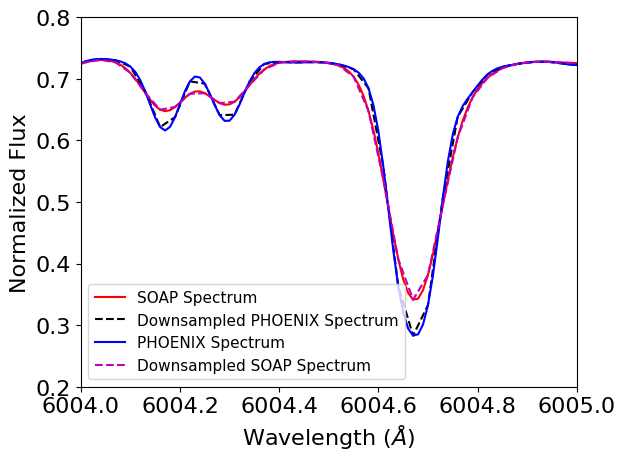

In [ ]:
# Compare the SOAP integrated spectrum, the original PHOENIX spectrum,
# and the downsampled PHOENIX spectrum in the same wavelength window.
plt.plot(wave_soap, flux_soap[0], 'r', label='SOAP Spectrum')
plt.plot(downsample_phoenix_wave, downsample_phoenix_flux, 'k--', label='Downsampled PHOENIX Spectrum')
plt.plot(wave_phoenix, flux_phoenix, 'b-', label='PHOENIX Spectrum')
plt.plot(downsample_soap_wave, downsample_soap_flux, 'm--', label='Downsampled SOAP Spectrum')
#plt.xlim(5903.6, 5904.3); plt.ylim(0.3,0.8)
plt.ylim(0.2,0.8); plt.xlim(6004., 6005)
plt.xlabel("Wavelength ("+r"$\AA$"+")")
plt.ylabel("Normalized Flux");
plt.legend(fontsize = 11)

### Do not downlample! Will work with SOAP spectrum

In [ ]:
# Export the SOAP, PHOENIX, and their downsampled spectra as ARVE-ready CSV files.
# Each file contains the columns: wave_val, flux_val, and flux_err.
csv_input_dir = Path("./saved_spectra/csv_spectra")
csv_input_dir.mkdir(parents=True, exist_ok=True)

def save_csv_spectra(path, wave, flux, flux_err=0.001):
    flux_array = np.asarray(flux)
    err_array = np.full(flux_array.shape, flux_err, dtype=float)
    spectrum_df = pd.DataFrame({
        "wave_val": np.asarray(wave),
        "flux_val": flux_array,
        "flux_err": err_array,
    })
    spectrum_df.to_csv(path, index=False)

save_csv_spectra(csv_input_dir / "soap.csv", wave_soap, flux_soap[0])
#save_csv_spectra(csv_input_dir / "phoenix.csv", wave_phoenix, flux_phoenix)
#save_csv_spectra(csv_input_dir / "soap_downsampled.csv", downsample_soap_wave, downsample_soap_flux)
#save_csv_spectra(csv_input_dir / "phoenix_downsampled.csv", downsample_phoenix_wave, downsample_phoenix_flux)

print(sorted(path.name for path in csv_input_dir.glob("*.csv")))


NameError: name 'wave' is not defined

In [46]:
def calculate_iccf_from_csv(
    spectrum_csv_path: str | Path,
    *,
    output_csv_path: str | Path,
    mask_name: str = "G2",
    mask_instrument: str = "ESPRESSO",
    spectrum_medium: str = "vacuum",
    mask_medium: str = "air",
    ccf_medium: str = "vacuum",
    rvarray: np.ndarray | None = None,
    mask_width: float = 0.5,
):
    try:
        import iCCF
        from iCCF.meta import espdr_compute_CCF_fast
    except ImportError as exc:
        raise ImportError(
            "iCCF is required for this calculation. Install it in the environment "
            "before using this function."
        ) from exc

    valid_media = {"air", "vacuum"}
    if spectrum_medium not in valid_media:
        raise ValueError("spectrum_medium must be 'air' or 'vacuum'.")
    if mask_medium not in valid_media:
        raise ValueError("mask_medium must be 'air' or 'vacuum'.")
    if ccf_medium not in valid_media:
        raise ValueError("ccf_medium must be 'air' or 'vacuum'.")

    def convert_wavelength_medium(wavelength, source_medium, target_medium):
        wavelength = np.asarray(wavelength, dtype=float)
        if source_medium == target_medium:
            return wavelength
        try:
            from airvacuumvald import air_to_vacuum, vacuum_to_air
        except ImportError as exc:
            raise ImportError(
                "airvacuumvald is required to convert between air and vacuum wavelengths."
            ) from exc

        if source_medium == "air" and target_medium == "vacuum":
            return air_to_vacuum(wavelength)
        if source_medium == "vacuum" and target_medium == "air":
            return vacuum_to_air(wavelength)
        raise ValueError(f"Unsupported wavelength conversion: {source_medium} -> {target_medium}")

    spec = pd.read_csv(spectrum_csv_path)
    wave = spec["wave_val"].to_numpy(float)
    flux = spec["flux_val"].to_numpy(float)
    err = spec["flux_err"].to_numpy(float)

    # Put the spectrum and mask on the same wavelength scale before computing the CCF.
    wave = convert_wavelength_medium(wave, spectrum_medium, ccf_medium)

    dll = np.diff(wave)
    dll = np.r_[dll, dll[-1]]
    blaze = np.ones_like(wave)
    quality = np.zeros_like(wave, dtype=int)
    if rvarray is None:
        rvarray = np.arange(-15.0, 15.0 + 0.1, 0.1)

    mask_obj = iCCF.Mask(mask_name, instrument=mask_instrument)
    mask_wavelength = convert_wavelength_medium(
        mask_obj.wavelength,
        mask_medium,
        ccf_medium,
    )

    mask = np.zeros(mask_obj.nlines, dtype=[("lambda", "f8"), ("contrast", "f8")])
    mask["lambda"] = mask_wavelength
    mask["contrast"] = mask_obj.contrast
    mask.sort(order="lambda")

    ccf, ccfe, ccfq = espdr_compute_CCF_fast(
        wave,
        dll,
        flux,
        err,
        blaze,
        quality,
        rvarray,
        mask,
        berv=0.0,
        bervmax=0.0,
        mask_width=mask_width,
    )

    output_csv_path = Path(output_csv_path)
    output_csv_path.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(
        {
            "ccf_vrad": rvarray,
            "ccf_val": ccf,
            "ccf_err": ccfe,
            "ccf_quality": ccfq,
        }
    ).to_csv(output_csv_path, index=False)

    return {
        "ccf_csv": output_csv_path,
        "ccf_vrad": rvarray,
        "ccf_val": ccf,
        "ccf_err": ccfe,
        "ccf_quality": ccfq,
        "ccf_medium": ccf_medium,
        "spectrum_medium": spectrum_medium,
        "mask_medium": mask_medium,
    }


In [ ]:
import iCCF
import pandas as pd

I = iCCF.Indicators(rvarray, ccf1, ccfe)

indicators = {
    "RV [km/s]": I.RV*1000,
    "FWHM [km/s]": I.FWHM,
    "BIS [km/s]": I.BIS*1000,
    "Vspan [km/s]": I.Vspan*1000,
    "Wspan [km/s]": I.Wspan*1000,
    "contrast [%]": I.contrast,
}

pd.Series(indicators)

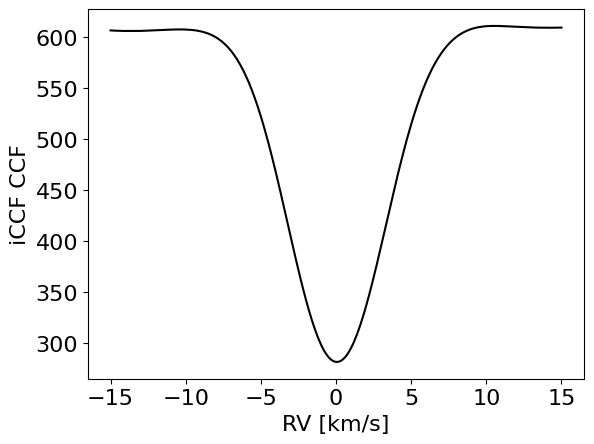

In [51]:
import iCCF
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from iCCF.meta import espdr_compute_CCF_fast

spec = pd.read_csv("./saved_spectra/csv_spectra/soap_spectrum_ar1_spot_lonm80_latp0_size0p05_dT200.csv")
mask_df = pd.read_csv("./saved_spectra/G2_mask.csv")

wave = spec["wave_val"].to_numpy(float)
flux = spec["flux_val"].to_numpy(float)
err = spec["flux_err"].to_numpy(float)

dll = np.diff(wave)
dll = np.r_[dll, dll[-1]]

blaze = np.ones_like(wave)
quality = np.zeros_like(wave, dtype=int)
rvarray = np.arange(-15.0, 15.0 + 0.1, 0.1)

mask = np.zeros(len(mask_df), dtype=[("lambda", "f8"), ("contrast", "f8")])
mask["lambda"] = mask_df["wave"].to_numpy(float)
mask["contrast"] = mask_df["depth"].to_numpy(float)
mask.sort(order="lambda")

ccf1, ccfe, ccfq = espdr_compute_CCF_fast(
    wave, dll, flux, err, blaze, quality,
    rvarray, mask,
    berv=0.0,
    bervmax=0.0,
    mask_width=0.5,  # HARPS-like; use 0.5 for ESPRESSO-like
)

plt.plot(rvarray, ccf1, "-k")
plt.xlabel("RV [km/s]")
plt.ylabel("iCCF CCF")
plt.show()


In [88]:
import iCCF
import pandas as pd

I = iCCF.Indicators(rvarray, ccf1, ccfe)

indicators = {
    "RV [km/s]": I.RV*1000,
    "FWHM [km/s]": I.FWHM,
    "BIS [km/s]": I.BIS*1000,
    "Vspan [km/s]": I.Vspan*1000,
    "Wspan [km/s]": I.Wspan*1000,
    "contrast [%]": I.contrast,
}

pd.Series(indicators)


RV [km/s]        65.456742
FWHM [km/s]       7.346592
BIS [km/s]       13.815742
Vspan [km/s]     12.274310
Wspan [km/s]   -390.757378
contrast [%]     54.264458
dtype: float64

In [11]:
import iCCF
import pandas as pd

I = iCCF.Indicators(rvarray, ccf, ccfe)

indicators = {
    "RV [km/s]": I.RV*1000,
    "RVerror [km/s]": I.RVerror,
    "FWHM [km/s]": I.FWHM,
    "FWHMerror [km/s]": I.FWHMerror,
    "BIS [km/s]": I.BIS,
    "BISerror [km/s]": I.BISerror,
    "Vspan [km/s]": I.Vspan,
    "Wspan [km/s]": I.Wspan,
    "DeltaV [km/s]": I.DeltaV,
    "contrast [%]": I.contrast,
    "contrast_error [%]": I.contrast_error,
}

pd.Series(indicators)


RV [km/s]             65.792381
RVerror [km/s]         0.000035
FWHM [km/s]            7.386727
FWHMerror [km/s]       0.000070
BIS [km/s]             0.013134
BISerror [km/s]        0.000070
Vspan [km/s]           0.012809
Wspan [km/s]          -0.385421
DeltaV [km/s]         -0.005394
contrast [%]          53.964540
contrast_error [%]     0.000512
dtype: float64

In [ ]:
# Generate random RV shifts and compute CCF values in a row-wise dataset
# (one sample per row, no RV-as-column-name keys) with one global progress bar.

def sample_random_rvs_ms(n_samples, rv_range_ms, random_seed=42):
    rng = np.random.default_rng(random_seed)
    return rng.uniform(rv_range_ms[0], rv_range_ms[1], size=n_samples)

def build_shifted_spectrum_csv(input_csv, shifted_csv, rv_ms, fill_value=1.0):
    shift_spectrum_csv(
        input_csv=input_csv,
        output_csv=shifted_csv,
        rv=rv_ms / 1000.0,
        fill_value=fill_value,
    )
    return shifted_csv

def compute_ccf_val_vector(shifted_csv, mask_csv, vrad_grid, quiet_arve=True):
    if quiet_arve:
        with open(os.devnull, "w") as fnull, redirect_stdout(fnull), redirect_stderr(fnull):
            arve_result = create_arve_ccf(
                input_spectrum=shifted_csv,
                mask_path=mask_csv,
                vrad_grid=vrad_grid,
            )
    else:
        arve_result = create_arve_ccf(
            input_spectrum=shifted_csv,
            mask_path=mask_csv,
            vrad_grid=vrad_grid,
        )
    return np.asarray(arve_result["ccf_val"], dtype=float)[0]

def build_ccf_rows_dataframe(input_csv, mask_csv, sampled_rv_ms, vrad_grid, fill_value=1.0, quiet_arve=True):
    input_csv = Path(input_csv)
    mask_csv = Path(mask_csv)

    rows = []

    with TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)

        for i, rv_ms in enumerate(tqdm(sampled_rv_ms, total=len(sampled_rv_ms), desc="Computing CCFs")):
            shifted_csv = tmpdir / f"{input_csv.stem}_rv_{i:05d}.csv"
            build_shifted_spectrum_csv(input_csv, shifted_csv, rv_ms, fill_value=fill_value)

            ccf_vec = compute_ccf_val_vector(
                shifted_csv=shifted_csv,
                mask_csv=mask_csv,
                vrad_grid=vrad_grid,
                quiet_arve=quiet_arve,
            )

            row = {
                "sample_index": int(i),
                "rv_shift_ms": float(rv_ms),
            }
            row.update({f"ccf_{j:04d}": float(val) for j, val in enumerate(ccf_vec)})
            rows.append(row)

    dataset_df = pd.DataFrame(rows)

    # Integrity checks to avoid silent shape drift.
    expected_samples = len(sampled_rv_ms)
    if len(dataset_df) != expected_samples:
        raise ValueError(f"Expected {expected_samples} samples but built {len(dataset_df)} rows.")

    ccf_cols = [c for c in dataset_df.columns if c.startswith("ccf_")]
    if not ccf_cols:
        raise ValueError("No CCF columns were created.")

    return dataset_df

def run_random_rv_ccf_workflow(
    input_csv,
    mask_csv,
    ccf_output_csv,
    *,
    n_samples=2,
    rv_range_ms=(0.0, 0.0),
    vrad_grid=(-15.0, 15.0, 0.1),
    random_seed=42,
    fill_value=1.0,
    quiet_arve=True,
):
    sampled_rv_ms = sample_random_rvs_ms(
        n_samples=n_samples,
        rv_range_ms=rv_range_ms,
        random_seed=random_seed,
    )

    dataset_df = build_ccf_rows_dataframe(
        input_csv=input_csv,
        mask_csv=mask_csv,
        sampled_rv_ms=sampled_rv_ms,
        vrad_grid=vrad_grid,
        fill_value=fill_value,
        quiet_arve=quiet_arve,
    )

    ccf_output_csv = Path(ccf_output_csv)
    ccf_output_csv.parent.mkdir(parents=True, exist_ok=True)
    dataset_df.to_csv(ccf_output_csv, index=False)

    print("Saved dataset shape:", dataset_df.shape)
    return dataset_df

random_ccf_dataset_df = run_random_rv_ccf_workflow(
    input_csv="./saved_spectra/csv_spectra/soap.csv",
    mask_csv="./saved_spectra/G2_mask.csv",
    ccf_output_csv="./saved_spectra/random_1000ccf_with_rv_0001step.csv",
    n_samples=1,
    rv_range_ms=(0.0, 0.0),
    vrad_grid=(-15.0, 15.0, 0.1),
    random_seed=42,
    quiet_arve=True,
)

random_ccf_dataset_df.head()


Computing CCFs:   0%|          | 0/1 [00:00<?, ?it/s]

Saved dataset shape: (1, 303)


,sample_index,rv_shift_ms,ccf_0000,ccf_0001,ccf_0002,ccf_0003,ccf_0004,ccf_0005,ccf_0006,ccf_0007,...,ccf_0291,ccf_0292,ccf_0293,ccf_0294,ccf_0295,ccf_0296,ccf_0297,ccf_0298,ccf_0299,ccf_0300
0,0,0.0,0.697446,0.697563,0.697691,0.697824,0.697961,0.698109,0.69827,0.698436,...,0.698767,0.698631,0.698501,0.698384,0.69828,0.698184,0.698093,0.698011,0.697941,0.697876


In [ ]:
# Generate 100m/s shifted SOAP spectrum for testing.
shift_spectrum_csv(
    input_csv="./saved_spectra/csv_spectra/soap.csv",
    output_csv="./saved_spectra/csv_spectra/soap_100ms_shifted.csv",
    rv=100 / 1000.0,
    fill_value=1.0,
    )

,wave_val,flux_val,flux_err
0,3800.005268,0.522401,0.001
1,3800.011268,0.522945,0.001
2,3800.017268,0.523612,0.001
3,3800.023268,0.524340,0.001
4,3800.029268,0.525042,0.001
...,...,...,...
479993,7799.952602,0.481617,0.001
479994,7799.962602,0.481952,0.001
479995,7799.972602,0.482171,0.001
479996,7799.982602,0.482312,0.001


Extracting CCF RVs.
~~~~ Processed spectra:


100%|██████████| 1/1 [00:00<00:00,  3.71it/s]


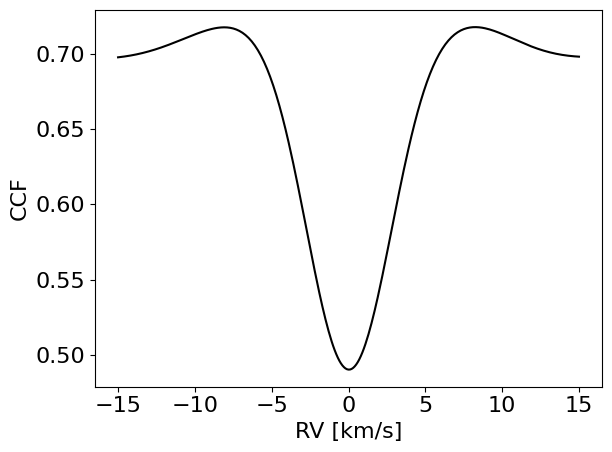

In [ ]:
# Example: compute one CCF from one input spectrum and one mask.
soap_arve_result = create_arve_ccf(
    input_spectrum="./saved_spectra/csv_spectra/soap.csv",
    mask_path="./saved_spectra/G2_mask.csv",
    vrad_grid=(-15.0, 15.0, 0.1),
)

ccf_vrad_soap = soap_arve_result["ccf_vrad"]
ccf_val_soap = soap_arve_result["ccf_val"]

soap_arve_ccf = pd.DataFrame(
    {
        "ccf_vrad": ccf_vrad_soap,
        "ccf_val": ccf_val_soap[0]
    }
)
soap_arve_ccf.to_csv("./saved_spectra/soap_arve_ccf.csv", index=False)

# Plot the CCF and RV results for the selected input spectrum.
fig, axs = plt.subplots(1)
axs.plot(ccf_vrad_soap, ccf_val_soap[0], "-k")
axs.set_ylabel("CCF")
axs.set_xlabel("RV [km/s]")
fig.align_ylabels()
plt.tight_layout()
plt.show()

Extracting CCF RVs.
~~~~ Processed spectra:


100%|██████████| 1/1 [00:00<00:00,  3.09it/s]


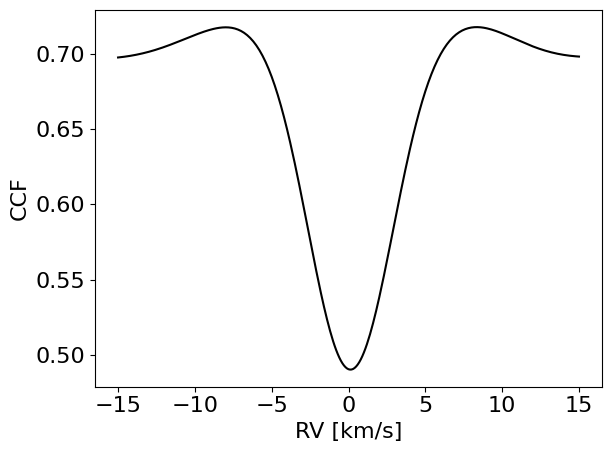

In [ ]:
# Example: compute one CCF from one input spectrum and one mask.
soap_100ms_shifted_arve_result = create_arve_ccf(
    input_spectrum="./saved_spectra/csv_spectra/soap_100ms_shifted.csv",
    mask_path="./saved_spectra/G2_mask.csv",
    vrad_grid=(-15.0, 15.0, 0.1),
)

ccf_vrad_soap_100ms_shifted = soap_100ms_shifted_arve_result["ccf_vrad"]
ccf_val_soap_100ms_shifted = soap_100ms_shifted_arve_result["ccf_val"]

soap_100ms_shifted_arve_ccf = pd.DataFrame(
    {
        "ccf_vrad": ccf_vrad_soap_100ms_shifted,
        "ccf_val": ccf_val_soap_100ms_shifted[0]
    }
)
soap_100ms_shifted_arve_ccf.to_csv("./saved_spectra/soap_100ms_shifted_arve_ccf.csv", index=False)

# Plot the CCF and RV results for the selected input spectrum.
fig, axs = plt.subplots(1)
axs.plot(ccf_vrad_soap_100ms_shifted, ccf_val_soap_100ms_shifted[0], "-k")
axs.set_ylabel("CCF")
axs.set_xlabel("RV [km/s]")
fig.align_ylabels()
plt.tight_layout()
plt.show()

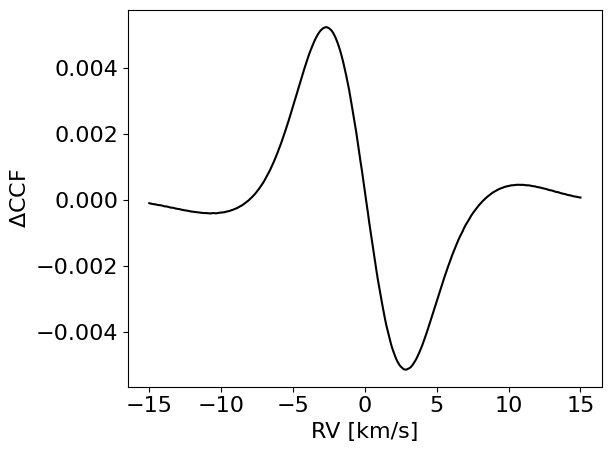

In [ ]:
fig, axs = plt.subplots(1)
axs.plot(ccf_vrad_soap_100ms_shifted, ccf_val_soap_100ms_shifted[0] - ccf_val_soap[0], "-k")
axs.set_xlabel("RV [km/s]")
axs.set_ylabel("$\Delta$CCF")
fig.align_ylabels()
plt.tight_layout()
plt.show()